# SPANet versus `hhbtag`: HH assignment failure diagnostics

This notebook compares the existing ColumnFlow `HHBJet` selection, which uses the
analysis `hhbtag` tagger, with the stored `SPANetHHBJet` selection. It uses the
same reduced VBF HH events and the same truth matching definition for both
methods.

The goal is to identify which events explain the remaining HH assignment gap,
rather than training another `hhbtag` model.


## 1. Load reduced events

The primary comparison is performed on VBF HH events. The code accepts either
the local SSHFS path or the original Manivald `/local` path.


In [1]:
from glob import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

BASE_CANDIDATES = [
    Path("/home/norman/UHHAnalysis/test_tt/spanet_v9"),
    Path("/local/norman/UHHAnalysis/test_tt/spanet_v9"),
]
BASE_DIR = next((path for path in BASE_CANDIDATES if path.exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError(f"Could not find reduced VBF HH directory: {BASE_CANDIDATES}")

files = sorted(glob(str(BASE_DIR / "events_*.parquet")))
if not files:
    raise FileNotFoundError(f"No parquet files found in {BASE_DIR}")

print("Input directory:", BASE_DIR)
print("Parquet files:", len(files))
for file in files:
    print(" -", file)


Input directory: /local/norman/UHHAnalysis/test_tt/spanet_v9
Parquet files: 6
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_0.parquet
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_1.parquet
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_2.parquet
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_3.parquet
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_4.parquet
 - /local/norman/UHHAnalysis/test_tt/spanet_v9/events_5.parquet


## 2. Truth and pair utilities

In [2]:
SPANET_REPO_CANDIDATES = [Path("/home/norman/SPANet"), Path("/local/norman/UHHAnalysis/SPANet")]
SPANET_REPO = next((path for path in SPANET_REPO_CANDIDATES if path.exists()), None)
if SPANET_REPO is None:
    raise FileNotFoundError(f"Could not find SPANet repository: {SPANET_REPO_CANDIDATES}")
import sys
if str(SPANET_REPO) not in sys.path:
    sys.path.append(str(SPANET_REPO))

from utils.convert_hh_bbtautau_parquet import higgs_bb_truth, matched_truth_indices

UINT64_MISSING = np.iinfo(np.uint64).max
HHB_DR = 0.4

REQUIRED_COLUMNS = [
    "Jet.deterministic_seed", "Jet.pt", "Jet.eta", "Jet.phi", "Jet.mass",
    "HHBJet.deterministic_seed", "HHBJet.btagDeepFlavB", "HHBJet.hhbtag",
    "SPANetHHBJet.deterministic_seed", "SPANetHHBJet.btagDeepFlavB",
    "SPANetHHBJet.spanet_higgs_bb_detection_score",
    "SPANetHHBJet.spanet_hhb_assignment_score",
    "SPANetJet.deterministic_seed", "SPANetJet.btagDeepFlavB",
    "GenPart.pt", "GenPart.eta", "GenPart.phi", "GenPart.mass",
    "GenPart.pdgId", "GenPart.status", "GenPart.genPartIdxMother",
]

def pad_seed_pair(collection):
    values = ak.pad_none(collection.deterministic_seed, 2, axis=1, clip=True)
    values = ak.fill_none(values, np.uint64(UINT64_MISSING))
    return ak.to_numpy(values)

def pad_pair_field(collection, field, fill=np.nan):
    values = ak.pad_none(collection[field], 2, axis=1, clip=True)
    values = ak.fill_none(values, fill)
    return ak.to_numpy(values)

def truth_seed_pair(events):
    truth_b1, truth_b2 = matched_truth_indices(higgs_bb_truth(events), events.Jet, HHB_DR)
    indices = np.column_stack([truth_b1, truth_b2])
    valid = np.all(indices >= 0, axis=1)
    safe = indices.copy()
    safe[safe < 0] = 0
    jet_seeds = ak.to_numpy(ak.fill_none(ak.pad_none(events.Jet.deterministic_seed, 16, axis=1, clip=True), np.uint64(UINT64_MISSING)))
    seeds = jet_seeds[np.arange(len(jet_seeds))[:, None], safe]
    seeds[~valid] = UINT64_MISSING
    return seeds, valid

def pair_equal(selected, truth):
    return np.all(np.sort(selected, axis=1) == np.sort(truth, axis=1), axis=1)

def pair_contains_truth(selected, truth):
    return (selected[:, :, None] == truth[:, None, :]).any(axis=2).sum(axis=1)


## 3. Build event-level comparison table

In [3]:
rows = []
for file_index, file in enumerate(files, start=1):
    print(f"[{file_index}/{len(files)}] {file}")
    events = ak.from_parquet(file, columns=REQUIRED_COLUMNS)
    truth_pair, truth_valid = truth_seed_pair(events)
    tagger_pair = pad_seed_pair(events.HHBJet)
    spanet_pair = pad_seed_pair(events.SPANetHHBJet)

    tagger_valid = np.all(tagger_pair != UINT64_MISSING, axis=1)
    spanet_valid = np.all(spanet_pair != UINT64_MISSING, axis=1)
    tagger_correct = truth_valid & tagger_valid & pair_equal(tagger_pair, truth_pair)
    spanet_correct = truth_valid & spanet_valid & pair_equal(spanet_pair, truth_pair)

    tagger_btag = pad_pair_field(events.HHBJet, "btagDeepFlavB")
    spanet_btag = pad_pair_field(events.SPANetHHBJet, "btagDeepFlavB")
    spanet_det = pad_pair_field(events.SPANetHHBJet, "spanet_higgs_bb_detection_score")[:, 0]
    spanet_assign = pad_pair_field(events.SPANetHHBJet, "spanet_hhb_assignment_score")[:, 0]
    n_jets = ak.to_numpy(ak.num(events.Jet, axis=1))

    for index in range(len(events)):
        if not truth_valid[index]:
            continue
        rows.append({
            "event_index": index,
            "file_index": file_index - 1,
            "n_jets": int(n_jets[index]),
            "truth_pair": tuple(int(x) for x in truth_pair[index]),
            "hhbtag_pair": tuple(int(x) for x in tagger_pair[index]) if tagger_valid[index] else None,
            "spanet_pair": tuple(int(x) for x in spanet_pair[index]) if spanet_valid[index] else None,
            "hhbtag_correct": bool(tagger_correct[index]),
            "spanet_correct": bool(spanet_correct[index]),
            "category": (
                "both correct" if tagger_correct[index] and spanet_correct[index]
                else "hhbtag only" if tagger_correct[index]
                else "SPANet only" if spanet_correct[index]
                else "both wrong"
            ),
            "hhbtag_btag_mean": float(np.nanmean(tagger_btag[index])),
            "spanet_btag_mean": float(np.nanmean(spanet_btag[index])),
            "spanet_detection_score": float(spanet_det[index]),
            "spanet_assignment_score": float(spanet_assign[index]),
        })
    del events

diagnostics = pd.DataFrame(rows)
print("Truth-ready events:", len(diagnostics))
diagnostics.head()


[1/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_0.parquet
[2/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_1.parquet
[3/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_2.parquet
[4/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_3.parquet
[5/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_4.parquet
[6/6] /local/norman/UHHAnalysis/test_tt/spanet_v9/events_5.parquet
Truth-ready events: 98242


,event_index,file_index,n_jets,truth_pair,hhbtag_pair,spanet_pair,hhbtag_correct,spanet_correct,category,hhbtag_btag_mean,spanet_btag_mean,spanet_detection_score,spanet_assignment_score
0,2,0,4,"(937963956708648427, 17078700763883723790)","(937963956708648427, 17078700763883723790)","(937963956708648427, 17078700763883723790)",True,True,both correct,0.998291,0.998291,0.981701,0.999910
1,3,0,2,"(9557662983565802535, 18444070279789013755)","(9557662983565802535, 18444070279789013755)","(9557662983565802535, 18444070279789013755)",True,True,both correct,0.520569,0.520569,0.964689,0.999234
2,4,0,2,"(4584414354706914111, 6837792918824935021)","(4584414354706914111, 6837792918824935021)","(4584414354706914111, 6837792918824935021)",True,True,both correct,0.574097,0.574097,0.913246,0.999962
3,5,0,3,"(15802827779893814348, 1538687737975580311)","(1538687737975580311, 15802827779893814348)","(1538687737975580311, 15802827779893814348)",True,True,both correct,0.999023,0.999023,0.964382,0.998397
4,9,0,3,"(17014152721772249030, 2512617673007414281)","(2512617673007414281, 17014152721772249030)","(2512617673007414281, 17014152721772249030)",True,True,both correct,0.523682,0.523682,0.845178,0.999960


## 4. Overall performance and disagreement categories

In [4]:
summary = pd.DataFrame([
    {"method": "hhbtag", "exact_pair_efficiency_pct": 100 * diagnostics.hhbtag_correct.mean()},
    {"method": "SPANet", "exact_pair_efficiency_pct": 100 * diagnostics.spanet_correct.mean()},
])
display(summary)

category_summary = (diagnostics["category"].value_counts(normalize=True).mul(100).rename("fraction_pct").reset_index())
category_summary.columns = ["category", "fraction_pct"]
display(category_summary)


,method,exact_pair_efficiency_pct
0,hhbtag,96.589035
1,SPANet,93.694143


,category,fraction_pct
0,both correct,92.307771
1,hhbtag only,4.281265
2,both wrong,2.024592
3,SPANet only,1.386372


## 5. Where does SPANet lose the HH assignment?

,n_jets,events,hhbtag_efficiency_pct,spanet_efficiency_pct
0,2,39923,100.000000,96.939108
1,3,37522,96.244870,92.161932
2,4,15385,91.699708,90.958726
3,5,4261,88.312603,88.969725
4,6,933,85.852090,85.101822
5,7,179,87.150838,85.474860
6,8,32,75.000000,93.750000
7,9,6,50.000000,50.000000
8,10,1,0.000000,0.000000


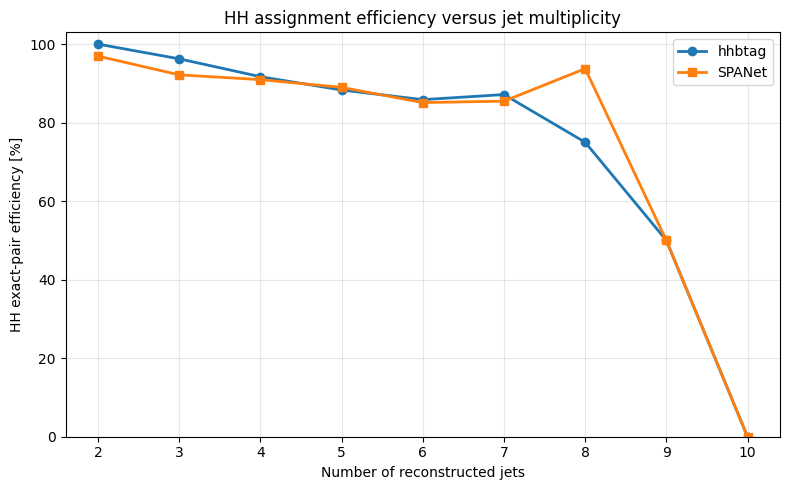

In [5]:
by_njets = diagnostics.groupby("n_jets", as_index=False).agg(
    events=("event_index", "size"),
    hhbtag_efficiency_pct=("hhbtag_correct", lambda x: 100 * x.mean()),
    spanet_efficiency_pct=("spanet_correct", lambda x: 100 * x.mean()),
)
display(by_njets)

fig, ax = plt.subplots(figsize=(8, 5))
for label, column, marker in [
    ("hhbtag", "hhbtag_efficiency_pct", "o"),
    ("SPANet", "spanet_efficiency_pct", "s"),
]:
    ax.plot(by_njets.n_jets, by_njets[column], marker=marker, linewidth=2, label=label)
ax.set_xlabel("Number of reconstructed jets")
ax.set_ylabel("HH exact-pair efficiency [%]")
ax.set_ylim(0, 103)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("HH assignment efficiency versus jet multiplicity")
plt.tight_layout()


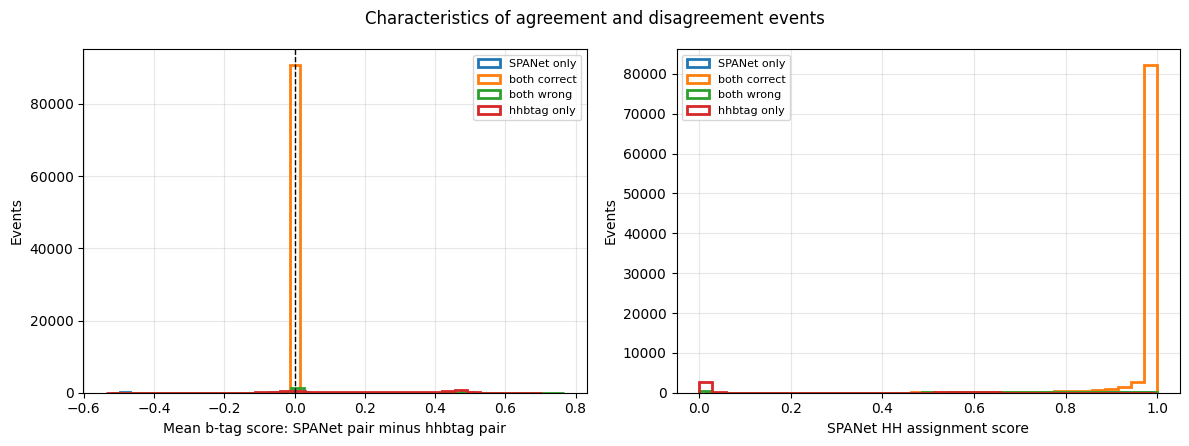

In [6]:
diagnostics["delta_btag_mean_spanet_minus_hhbtag"] = diagnostics.spanet_btag_mean - diagnostics.hhbtag_btag_mean

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for category, group in diagnostics.groupby("category"):
    axes[0].hist(group["delta_btag_mean_spanet_minus_hhbtag"], bins=35, histtype="step", linewidth=2, label=category)
    axes[1].hist(group["spanet_assignment_score"], bins=35, histtype="step", linewidth=2, label=category)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Mean b-tag score: SPANet pair minus hhbtag pair")
axes[0].set_ylabel("Events")
axes[1].set_xlabel("SPANet HH assignment score")
axes[1].set_ylabel("Events")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Characteristics of agreement and disagreement events")
plt.tight_layout()


## 6. Inspect representative disagreements

In [7]:
failure_view = diagnostics[
    (diagnostics.hhbtag_correct != diagnostics.spanet_correct)
].sort_values(["spanet_correct", "spanet_assignment_score"], ascending=[True, True])

display(failure_view.head(30))


,event_index,file_index,n_jets,truth_pair,hhbtag_pair,spanet_pair,hhbtag_correct,spanet_correct,category,hhbtag_btag_mean,spanet_btag_mean,spanet_detection_score,spanet_assignment_score,delta_btag_mean_spanet_minus_hhbtag
6,13,0,2,"(7830385677700792420, 14249115025822348000)","(7830385677700792420, 14249115025822348000)","(7830385677700792420, 7830385677700792420)",True,False,hhbtag only,0.502708,0.988770,0.304112,0.0,0.486061
12,26,0,2,"(1903763292352800493, 2386173084523874925)","(1903763292352800493, 2386173084523874925)","(2386173084523874925, 2386173084523874925)",True,False,hhbtag only,0.507629,0.988281,0.232420,0.0,0.480652
75,148,0,3,"(7487535928227565484, 17596474994096777818)","(17596474994096777818, 7487535928227565484)","(7487535928227565484, 7487535928227565484)",True,False,hhbtag only,0.206688,0.398682,0.087839,0.0,0.191994
88,167,0,2,"(11174931440542813156, 8544467477273182708)","(11174931440542813156, 8544467477273182708)","(8544467477273182708, 8544467477273182708)",True,False,hhbtag only,0.505615,0.928711,0.113558,0.0,0.423096
93,175,0,2,"(9099961014198981315, 10754269804593847093)","(10754269804593847093, 9099961014198981315)","(9099961014198981315, 9099961014198981315)",True,False,hhbtag only,0.578735,0.733398,0.845273,0.0,0.154663
140,252,0,3,"(3869683886672638567, 4221889024482172882)","(3869683886672638567, 4221889024482172882)","(3869683886672638567, 3869683886672638567)",True,False,hhbtag only,0.512314,0.975586,0.590879,0.0,0.463272
153,273,0,3,"(5180356794744987015, 12514861066169270959)","(12514861066169270959, 5180356794744987015)","(12514861066169270959, 12514861066169270959)",True,False,hhbtag only,0.518417,0.990234,0.115693,0.0,0.471817
217,397,0,2,"(5722359385188678709, 17447591321670393727)","(17447591321670393727, 5722359385188678709)","(17447591321670393727, 17447591321670393727)",True,False,hhbtag only,0.401863,0.795898,0.063868,0.0,0.394035
237,429,0,3,"(11430835565121347196, 14400703502358719901)","(14400703502358719901, 11430835565121347196)","(11430835565121347196, 11430835565121347196)",True,False,hhbtag only,0.745605,0.997559,0.648412,0.0,0.251953
243,437,0,3,"(3979979299397563454, 9227606611791018732)","(9227606611791018732, 3979979299397563454)","(3979979299397563454, 3979979299397563454)",True,False,hhbtag only,0.270142,0.474609,0.252814,0.0,0.204468


## 6. Truth coverage of the SPANetJet input collection

This is a prerequisite check. It asks whether the generator-matched Higgs b jets are present in the `SPANetJet` collection before the network assigns a pair. A missing truth jet is a collection-selection limitation, not an assignment failure.

In [8]:
coverage_rows = []
coverage_by_njets = []
for file_index, file in enumerate(files, start=1):
    events = ak.from_parquet(file, columns=["Jet.deterministic_seed", "Jet.eta", "Jet.phi", "SPANetJet.deterministic_seed", "GenPart.pt", "GenPart.eta", "GenPart.phi", "GenPart.mass", "GenPart.pdgId", "GenPart.status", "GenPart.genPartIdxMother"])
    truth_pair, truth_valid = truth_seed_pair(events)
    spanet_values = ak.pad_none(events.SPANetJet.deterministic_seed, 16, axis=1, clip=True)
    spanet_values = ak.to_numpy(ak.fill_none(spanet_values, np.uint64(UINT64_MISSING)))
    truth_present = truth_valid
    b1_in = np.any(spanet_values == truth_pair[:, 0, None], axis=1) & truth_present
    b2_in = np.any(spanet_values == truth_pair[:, 1, None], axis=1) & truth_present
    pair_in = b1_in & b2_in
    n_jets = ak.to_numpy(ak.num(events.Jet, axis=1))
    coverage_rows.append({
        "file_index": file_index - 1,
        "events": len(events),
        "truth_ready_events": int(truth_present.sum()),
        "b1_in_spanetjet_pct": 100 * b1_in.sum() / truth_present.sum() if truth_present.any() else np.nan,
        "b2_in_spanetjet_pct": 100 * b2_in.sum() / truth_present.sum() if truth_present.any() else np.nan,
        "full_hh_pair_in_spanetjet_pct": 100 * pair_in.sum() / truth_present.sum() if truth_present.any() else np.nan,
        "missing_full_pair": int((truth_present & ~pair_in).sum()),
    })
    for n in np.unique(n_jets[truth_present]):
        sel = truth_present & (n_jets == n)
        coverage_by_njets.append({"file_index": file_index - 1, "n_jets": int(n), "events": int(sel.sum()), "full_hh_pair_in_spanetjet_pct": 100 * pair_in[sel].mean()})
    del events

coverage = pd.DataFrame(coverage_rows)
coverage_vs_njets = pd.DataFrame(coverage_by_njets)
display(coverage)
display(coverage_vs_njets)
coverage.to_csv(BASE_DIR / "spanetjet_truth_coverage.csv", index=False)
coverage_vs_njets.to_csv(BASE_DIR / "spanetjet_truth_coverage_vs_njets.csv", index=False)


,file_index,events,truth_ready_events,b1_in_spanetjet_pct,b2_in_spanetjet_pct,full_hh_pair_in_spanetjet_pct,missing_full_pair
0,0,30244,16382,100.0,100.0,100.0,0
1,1,33367,18048,100.0,100.0,100.0,0
2,2,35463,19200,100.0,100.0,100.0,0
3,3,21037,11333,100.0,100.0,100.0,0
4,4,31999,17485,100.0,100.0,100.0,0
5,5,29159,15794,100.0,100.0,100.0,0


,file_index,n_jets,events,full_hh_pair_in_spanetjet_pct
0,0,2,6612,100.0
1,0,3,6277,100.0
2,0,4,2630,100.0
3,0,5,687,100.0
4,0,6,140,100.0
5,0,7,27,100.0
6,0,8,8,100.0
7,0,9,1,100.0
8,1,2,7357,100.0
9,1,3,6887,100.0


## 7. Interpretation

The important cases are `hhbtag only`: these are events where the tagger finds
the truth (b)-jet pair but SPANet does not. Compare their jet multiplicity,
b-tag-score separation, and SPANet assignment score with the other categories.

This determines whether the next improvement should be a better b-tagging input
representation, an HH-specific training objective, or a multitask optimization
change. The notebook does not retrain either method.
